1) Importamos librerías

In [1]:
import matplotlib.pyplot as plt

import gudhi as gd 
import numpy as np 
import tensorflow as tf 
import pandas as pd

from utils import *

from matplotlib import gridspec
from matplotlib.colors import Normalize
import matplotlib.cm as cm

import wfdb
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [33]:
wfdb.dl_database("mitdb", dl_dir="mitbih_data")

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

KeyboardInterrupt: 

2) Definimos funciones

In [2]:

def load_mitbih_beats(record_id="100", window=200):

    record = wfdb.rdrecord(f"mitbih_data/{record_id}")
    annotation = wfdb.rdann(f"mitbih_data/{record_id}", "atr")

    signal = record.p_signal[:, 0]  # MLII

    X = []
    y = []

    for i, label in enumerate(annotation.symbol):

        if label not in ["N", "V"]:  # binario simple para empezar
            continue

        idx = annotation.sample[i]

        if idx - window < 0 or idx + window > len(signal):
            continue

        beat = signal[idx - window: idx + window]

        X.append(beat)
        y.append(0 if label == "N" else 1)

    return np.array(X), np.array(y)


def signal_to_curve(signal):
    """
    Converts 1D time series into 2D curve safely.
    """
    signal = np.array(signal).astype(float).squeeze()  # 🔴 clave

    t = np.arange(len(signal)).astype(float)

    # normalize
    x = (t - np.min(t)) / (np.max(t) - np.min(t) + 1e-8)
    y = (signal - np.min(signal)) / (np.max(signal) - np.min(signal) + 1e-8)

    return x, y


def build_dataset_from_ecg(layer, n_points=400):
    """
    Builds PET dataset from TwoLeadECG.
    """
    X_raw, y_raw = load_mitbih_beats(record_id=106)

    X_pet = []
    y_labels = []

    for signal, label in zip(X_raw, y_raw):

        # convert signal to geometric curve
        x, y = signal_to_curve(signal)

        # resample to fixed number of points (important for PET stability)
        idx = np.linspace(0, len(x) - 1, n_points).astype(int)
        x = x[idx]
        y = y[idx]

        pet, _ = compute_pet_from_shape(x, y, layer)

        X_pet.append(pet)
        y_labels.append(int(label))

    return np.array(X_pet), np.array(y_labels)


def experiment_ecg(layer, n_points=400):

    print("\n=== PET Classification on TwoLeadECG ===")

    X, y = build_dataset_from_ecg(layer, n_points=n_points)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=0, stratify=y
    )

    clf = SVC(kernel="linear")
    clf.fit(X_train, y_train)

    preds = clf.predict(X_test)
    acc = accuracy_score(y_test, preds)

    print("Accuracy:", acc)

    return acc

def plot_two_signals(X, y):
    """
    Plots one example per class from TwoLeadECG.
    """

    X = np.array(X)
    y = np.array(y)

    # find one sample per class
    idx_class_0 = np.where(y == 0)[0]
    idx_class_1 = np.where(y == 1)[0]

    sig0 = np.squeeze(X[idx_class_0])
    sig1 = np.squeeze(X[idx_class_1])

    t0 = np.arange(len(sig0))
    t1 = np.arange(len(sig1))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(t0, sig0)
    plt.title("TwoLeadECG - Class (Normal)")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")

    plt.subplot(1, 2, 2)
    plt.plot(t1, sig1)
    plt.title("TwoLeadECG - Class 1 (PVC)")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")

    plt.tight_layout()
    plt.show()

def build_lowerstar_layer(n_points):

    stbase = gd.SimplexTree()

    for i in range(n_points-1):
        stbase.insert([i,i+1], -1e10)

    layer = LowerStarLayer(simplextree=stbase)
    return layer

def compute_pet_from_shape(x, y, layer, num_directions=64):

    x_tf = tf.constant(x, dtype=tf.float32)
    y_tf = tf.constant(y, dtype=tf.float32)

    PET_values, angles = persistent_entropy_transform(
        x_tf,
        y_tf,
        layer,
        num_directions=num_directions
    )

    return PET_values.numpy(), angles

3) Vemos el dataset

In [3]:
X, y = load_mitbih_beats(record_id=106)

print(X.shape)
print(y.shape)

unique, counts = np.unique(y, return_counts=True)

dict(zip(unique, counts))


(2027, 400)
(2027,)


{np.int64(0): np.int64(1507), np.int64(1): np.int64(520)}

1162 señales de longitud 82, con una muestra balanceada: 581 ecg clasificadas en tipo 1 y 581 clasificadas en tipo 2. Tipo 1 es latidos con patron normal, tipo 2 es latido con morfologia istinta.

4) Visualizamos señales de ambos tipos

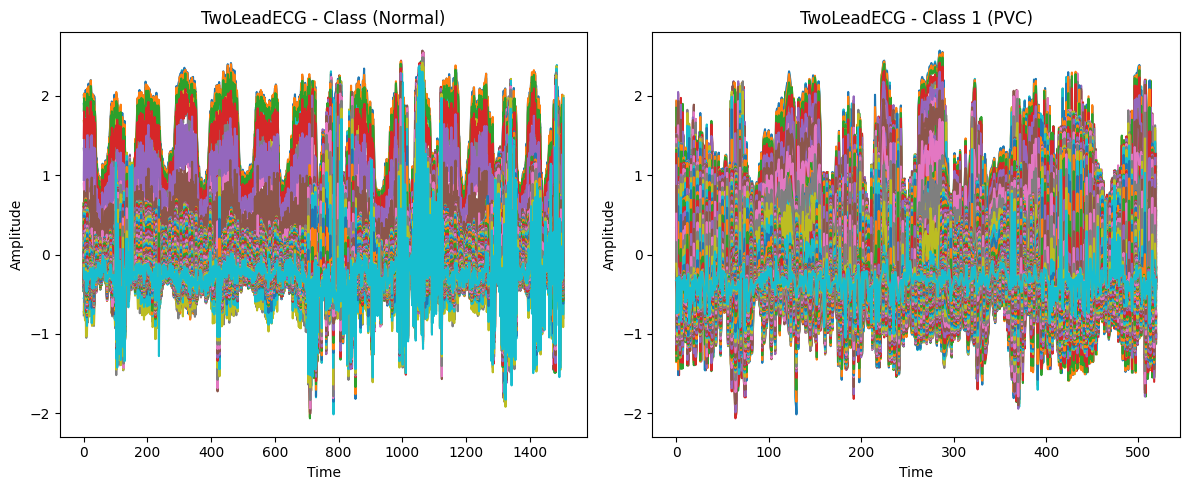

In [4]:
plot_two_signals(X,y)

5) Run SVM using PET as input data

In [5]:
n_points = 400
layer = build_lowerstar_layer(n_points)

experiment_ecg(layer, n_points=n_points)


=== PET Classification on TwoLeadECG ===
Accuracy: 0.9917898193760263


0.9917898193760263

En total

In [28]:
records = [
    "100","101","102","103","104","105","106","107","108","109",
    "111","112","113","114","115","116","117","118","119","121",
    "122","123","124","200","201","202","203","205","207","208",
    "209","210","212","213","214"
]

def load_mitbih_all(records, window=200, classes=("N", "V")):
    """
    Loads all MIT-BIH records into a single dataset.

    Returns:
        X: (n_beats, 2*window)
        y: (n_beats,)
    """

    X_all = []
    y_all = []

    for rec in records:

        try:
            record = wfdb.rdrecord(f"mitbih_data/{rec}")
            ann = wfdb.rdann(f"mitbih_data/{rec}", "atr")

            signal = record.p_signal[:, 0]  # MLII

            for i, label in enumerate(ann.symbol):

                if label not in classes:
                    continue

                idx = ann.sample[i]

                if idx - window < 0 or idx + window >= len(signal):
                    continue

                beat = signal[idx - window: idx + window]

                X_all.append(beat)
                y_all.append(0 if label == classes[0] else 1)

        except Exception as e:
            print(f"Skipping record {rec}: {e}")

    return np.array(X_all), np.array(y_all)


X, y = load_mitbih_all(records)

print(X.shape)
print(y.shape)

unique, counts = np.unique(y, return_counts=True)

print(dict(zip(unique, counts)))

def balance_dataset(X, y):

    idx_n = np.where(y == 0)[0]
    idx_v = np.where(y == 1)[0]

    idx_n = np.random.choice(idx_n, size=len(idx_v), replace=False)

    idx = np.concatenate([idx_n, idx_v])

    return X[idx], y[idx]

X_new, y_new = balance_dataset(X,y)

(56906, 400)
(56906,)
{np.int64(0): np.int64(52234), np.int64(1): np.int64(4672)}
